In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from numpy.polynomial import Polynomial
import numpy as np


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


In [2]:
summary_mega_panel = pd.read_csv('../../2_figure_CL_benchmarking/output/gapfill_betaine_mega_summary.csv',index_col=0)

summary_mega_panel['gene'] = summary_mega_panel['gene'].str.replace('NF1_0','NF1')
summary_mega_panel['gene'] = summary_mega_panel['gene'].str.replace('NF1_1','NF1')

summary_mega_panel['name'] = summary_mega_panel.index
summary_mega_panel['CDS_location'] = summary_mega_panel['name'].str.extract(r'c\.(\d+)')[0].astype(float)

In [4]:
transcripts = pd.read_csv('../data/MANE_Select_transcript_lengths.tsv', sep='\t')
transcripts = transcripts.sort_values(['ensembl_transcript_id','cdna_coding_start']).copy()
# transcripts = transcripts.groupby(['ensembl_transcript_id','transcript_length','external_gene_name'])['cdna_coding_start'].min().reset_index().copy()

transcripts = transcripts.groupby(['ensembl_transcript_id','transcript_length','external_gene_name']).agg({
    'cdna_coding_start': 'min',
    'cdna_coding_end': 'max'
}).reset_index()

# transcripts['transcript_length'] = transcripts['cdna_coding_end'] ### this could be used if we want to exclude UTR
transcript_lengths = transcripts.set_index('external_gene_name')['transcript_length'].to_dict()
cdna_coding_starts = transcripts.set_index('external_gene_name')['cdna_coding_start'].to_dict()


In [5]:
summary_mega_panel['transcript_length'] = summary_mega_panel['gene'].map(transcript_lengths)
summary_mega_panel['cdna_coding_start'] = summary_mega_panel['gene'].map(cdna_coding_starts)
summary_mega_panel['transcript_location'] = summary_mega_panel['CDS_location'] + summary_mega_panel['cdna_coding_start'] - 1
summary_mega_panel['normalized_location'] = summary_mega_panel['transcript_location'] / summary_mega_panel['transcript_length']
summary_mega_panel = summary_mega_panel.dropna(subset='normalized_location')

344
PearsonRResult(statistic=0.020430358795344064, pvalue=0.7057374980943345)


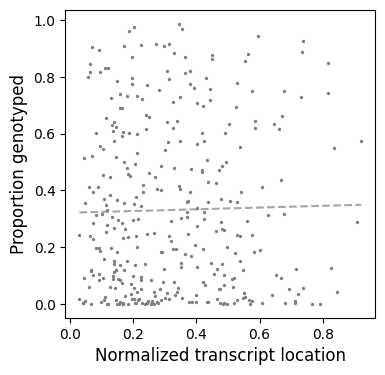

In [6]:
summary_mega_panel['to_plot'] = (summary_mega_panel['prop_genotyped'].copy())
to_plot = summary_mega_panel.dropna(subset=['to_plot'])
to_plot = to_plot.loc[to_plot['mean_0bp_count'] > 0.5].copy()
print(len(to_plot))

fig,ax = plt.subplots(figsize=(4,4))
ax.scatter(to_plot['normalized_location'],to_plot['to_plot'],color='grey',s=2,label='GIFT')
# Fit polynomial (degree 1 = linear) to GIFT data
gift_fit = Polynomial.fit(to_plot['normalized_location'], to_plot['to_plot'], 1)
x_range = [to_plot['normalized_location'].min(), to_plot['normalized_location'].max()]
x_vals = np.array(x_range, dtype=float)
ax.plot(x_vals, gift_fit(x_vals), color='grey', linestyle='--', alpha=0.7, label='GIFT trend')
ax.set_xlabel('Normalized transcript location', size=12)
ax.set_ylabel('Proportion genotyped', size=12)
ax.legend().set_visible(False)

print(st.pearsonr(to_plot['normalized_location'],to_plot['to_plot']))

plt.savefig('../plots/prop_genotyped_location_dependence.pdf', bbox_inches='tight', dpi=300)